# Stationarity Analysis and Differenced Series

## Purpose
Tests the raw training series for stationarity, applies **seasonal differencing** (lag-12) to remove the seasonal component, and confirms the differenced series is stationary using the Augmented Dickey-Fuller (ADF) test. The ACF and PACF of the stationary series are then plotted to inform the selection of ARIMA `p` and `q` parameters.

The differenced series is saved and used as input to the ARIMA modelling notebooks.

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)

## Outputs
- `data/stationary.csv` — Seasonally differenced series (81 observations)
- Inline plots: differenced series line plot, ACF, PACF

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from matplotlib import pyplot as plt

## Seasonal Differencing Helper

Computes a lag-`interval` differenced series: `y[t] - y[t - interval]`. With `interval=12` this removes the monthly seasonal cycle, which is the dominant source of non-stationarity in this data.

In [2]:
# create a differenced series
def difference(dataset, interval=1):
    diff = list()
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return pd.Series(diff)

## Load Training Data

Load the training series. The values will be cast to `float64` before differencing.

In [3]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Apply Seasonal Differencing and Test for Stationarity

Apply a 12-month seasonal difference and re-attach the correct `DatetimeIndex` (offset by 12 months to align with valid indices). The **Augmented Dickey-Fuller** test is then run on the differenced series.

An ADF statistic more negative than the critical value (and `p-value < 0.05`) provides statistical evidence that the series is stationary and suitable for ARIMA modelling without further differencing.

In [4]:
X = series.values
X = X.astype('float64')
# difference data
months_in_year = 12
stationary = difference(X, months_in_year)
stationary.index = series.index[months_in_year:]
# check if stationary
result = adfuller(stationary)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -7.134898
p-value: 0.000000
Critical Values:
	1%: -3.515
	5%: -2.898
	10%: -2.586


## Save Differenced Series

Persist the stationary series to `data/stationary.csv` without a header row, ready for downstream use.

In [5]:
# save
stationary.to_csv('data/stationary.csv', header=False)

## Plot Differenced Series

Visually verify that the trend and seasonal level-shifts have been removed. The series should now oscillate around a roughly constant mean.

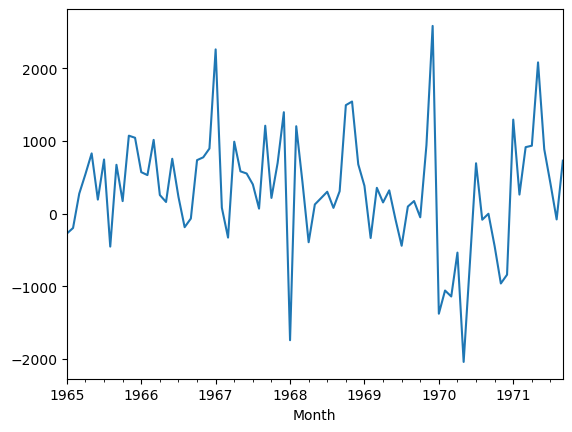

In [6]:
# plot
stationary.plot();

## ACF and PACF

Plot the **Autocorrelation Function** (ACF) and **Partial Autocorrelation Function** (PACF) up to 25 lags on the stationary series.

- The **PACF** informs the AR order `p`: count the lags that are significant before the plot cuts off.
- The **ACF** informs the MA order `q`: count the lags that are significant before the plot cuts off.


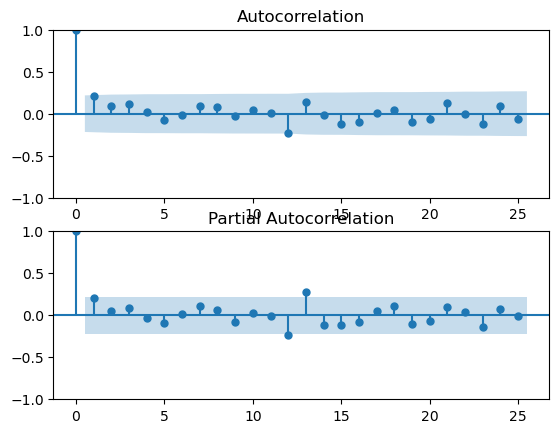

In [7]:
plt.figure();
plt.subplot(211);
plot_acf(stationary, lags=25, ax=plt.gca());
plt.subplot(212);
plot_pacf(stationary, lags=25, ax=plt.gca());